<a href="https://colab.research.google.com/github/Ahmedaboenaba/Machine-Learning/blob/main/Neural%20Networks/CNN/Digit_Recognizer_by_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digit Recognizer using CNN

## Objective
using CNN as an introduction to imaging datasets to learn how to CNN used in computer vision.

### Notebook and data are from kaggle competitions
https://www.kaggle.com/code/yassineghouzam/introduction-to-cnn-keras-0-997-top-6/notebook

### Pipeline
1. Necessary Libraries and data loading
2. Data preparation

    2.1 Load data                                                               
    2.2 Check for null and missing values                                       
    2.3 Normalization                                                           
    2.4 Reshape                                                                 
    2.5 Label encoding                                                          
    2.6 Split training and valdiation set

3. CNN

    3.1 Define the model                                                        
    3.2 Set the optimizer and annealer                                          
    3.3 Data augmentation                                                       

4. Evaluate the model

    4.1 Training and validation curves                                          
    4.2 Confusion matrix                                                        

5. Prediction and submition

    5.1 Predict and Submit results                                              



### Necessary Libraries

In [1]:
#Data Manipulation
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
np.random.seed(2)

#data Visualization
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
%matplotlib inline
sns.set(style='white', context='notebook', palette='deep')

#Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import itertools

#CNN
from tensorflow.keras.utils import to_categorical #convert to one hot encoding
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator #generate dataset
from keras.callbacks import ReduceLROnPlateau



### data Loading

In [2]:
train = pd.read_csv('/content/drive/MyDrive/DEPI/Neural Networks/CNN/Datasets/Digit Recognizer by CNN project/Copy of train.csv')
test = pd.read_csv('/content/drive/MyDrive/DEPI/Neural Networks/CNN/Datasets/Digit Recognizer by CNN project/Copy of test.csv')

In [3]:
train
#42,000 image each with 784(28*28) feature and one label

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
#Split dataset
y_train = train['label']
X_train = train.drop(labels=['label'],axis=1)

#free some space
del train


###Exploring (Indexing)

In [5]:
y_train.value_counts()

,count
label,
1,4684
7,4401
3,4351
9,4188
2,4177
6,4137
0,4132
4,4072
8,4063


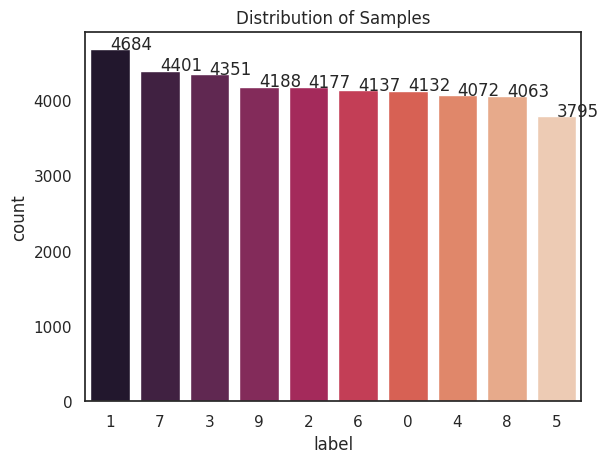

In [6]:
#visualize distribution of samples
sns.countplot(x=y_train, order=y_train.value_counts().index,palette='rocket')
plt.title('Distribution of Samples')
#count on each sample
for i, val in enumerate(y_train.value_counts()):
    plt.text(i, val, val)
plt.show()

In [7]:
#Check Missing
X_train.isnull().any().describe()

,0
count,784
unique,1
top,False
freq,784


In [8]:
test.isnull().any().describe()

,0
count,784
unique,1
top,False
freq,784


In [9]:
X_train.shape

(42000, 784)

In [10]:
test.shape

(28000, 784)

###Cleaning

In [11]:
#Normalization
X_train= X_train/255.0
test = test/255.0

In [12]:
#Reshaping
X_train = X_train.values.reshape(-1,28,28,1) #-1: number of images in whole data, 28px*28px, canal:1 channel as my image is gray not rgb
test = test.values.reshape(-1,28,28,1) #Change the size of image form 1 vector of 784 value to 2D image

In [13]:
X_train.shape

(42000, 28, 28, 1)

In [14]:
test.shape

(28000, 28, 28, 1)

In [15]:
#Label Encoding
#outpit is preferred to be one hot encoding as we will work softmax as multi class
y_train = to_categorical(y_train, num_classes=10)

In [16]:
#Example
y_train[2]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [17]:
#split data into training and validation
X_train,X_val,y_train,y_val = train_test_split(X_train,y_train,test_size=0.1,random_state=2)

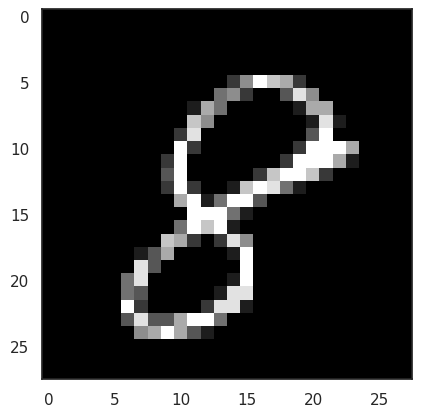

In [18]:
#Visualize image example
plt.imshow(X_train[0][:,:,0],cmap='gray')
plt.show()

In [19]:
y_train[0]
# 9th index is 1 and the rest is 0. ythis means that this value belongs to 8

array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])

## CNN

In [20]:
#build model
model = Sequential()

#feature Extraction
model.add(Conv2D(filters=32,kernel_size=(5,5),padding='Same',activation='relu',input_shape=(28,28,1)))
model.add(Conv2D(filters=32,kernel_size=(5,5),padding='Same',activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters=64,kernel_size=(3,3),padding='Same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=(3,3),padding='Same',activation='relu'))
model.add(MaxPool2D(pool_size=(2,2),strides=(2,2)))
model.add(Dropout(0.25))

#Feed Forrward NN
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 887,530 (3.39 MB)

 Trainable params: 887,530 (3.39 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
#Compile
optimizer = RMSprop(learning_rate=0.001,rho=0.9,epsilon=1e-08,decay=0.0)

In [24]:
model.compile(optimizer=optimizer,loss='categorical_crossentropy',metrics=['accuracy'])

In [25]:
#Callbacks
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',patience=7,restore_best_weights=True)

callbacks = [early_stop,learning_rate_reduction]

In [26]:
epochs = 100
batch_size = 64

In [27]:
#train model without augmentation
history_without_aug = model.fit(X_train,y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(X_val,y_val),
                    callbacks=callbacks)

Epoch 1/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.8268 - loss: 0.5336 - val_accuracy: 0.9812 - val_loss: 0.0595 - learning_rate: 0.0010
Epoch 2/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9764 - loss: 0.0792 - val_accuracy: 0.9883 - val_loss: 0.0410 - learning_rate: 0.0010
Epoch 3/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9842 - loss: 0.0545 - val_accuracy: 0.9833 - val_loss: 0.0515 - learning_rate: 0.0010
Epoch 4/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9870 - loss: 0.0422 - val_accuracy: 0.9902 - val_loss: 0.0370 - learning_rate: 0.0010
Epoch 5/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9877 - loss: 0.0397 - val_accuracy: 0.9914 - val_loss: 0.0315 - learning_rate: 0.0010
Epoch 6/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9886 - loss: 0.0388 - val_accuracy: 0.9902 - val_loss: 0.0493 - learning_rate: 0.0010
Epoch 7/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9901 - loss: 

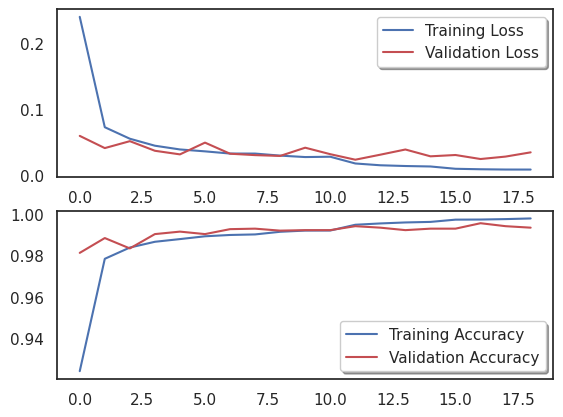

In [29]:
#visualize training and validation Vs Loss
fig,ax = plt.subplots(2,1)
ax[0].plot(history_without_aug.history['loss'],color='b',label='Training Loss')
ax[0].plot(history_without_aug.history['val_loss'],color='r',label='Validation Loss')
legend = ax[0].legend(loc='best',shadow=True)

ax[1].plot(history_without_aug.history['accuracy'],color='b',label='Training Accuracy')
ax[1].plot(history_without_aug.history['val_accuracy'],color='r',label='Validation Accuracy')
legend = ax[1].legend(loc='best',shadow=True)

### Augmentation

In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,
    vertical_flip=False)

datagen.fit(X_train)

In [31]:
history_with_aug = model.fit(datagen.flow(X_train,y_train,batch_size=batch_size),
                             epochs = epochs,
                             validation_data = (X_val,y_val),
                             verbose = 2,
                             callbacks=callbacks)

Epoch 1/100
591/591 - 22s - 37ms/step - accuracy: 0.9642 - loss: 0.1219 - val_accuracy: 0.9933 - val_loss: 0.0236 - learning_rate: 2.5000e-04
Epoch 2/100
591/591 - 15s - 26ms/step - accuracy: 0.9757 - loss: 0.0827 - val_accuracy: 0.9929 - val_loss: 0.0287 - learning_rate: 2.5000e-04
Epoch 3/100
591/591 - 20s - 35ms/step - accuracy: 0.9787 - loss: 0.0733 - val_accuracy: 0.9926 - val_loss: 0.0292 - learning_rate: 2.5000e-04
Epoch 4/100
591/591 - 15s - 25ms/step - accuracy: 0.9808 - loss: 0.0654 - val_accuracy: 0.9938 - val_loss: 0.0226 - learning_rate: 2.5000e-04
Epoch 5/100
591/591 - 14s - 24ms/step - accuracy: 0.9826 - loss: 0.0607 - val_accuracy: 0.9926 - val_loss: 0.0262 - learning_rate: 2.5000e-04
Epoch 6/100
591/591 - 15s - 26ms/step - accuracy: 0.9843 - loss: 0.0537 - val_accuracy: 0.9929 - val_loss: 0.0304 - learning_rate: 2.5000e-04
Epoch 7/100
591/591 - 14s - 24ms/step - accuracy: 0.9840 - loss: 0.0547 - val_accuracy: 0.9948 - val_loss: 0.0211 - learning_rate: 2.5000e-04
Epoch 

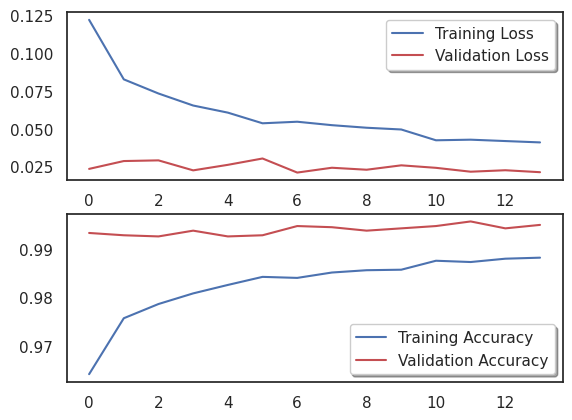

In [32]:
#Visualize train and validation Vs Loss
fig,ax = plt.subplots(2,1)
ax[0].plot(history_with_aug.history['loss'],color='b',label='Training Loss')
ax[0].plot(history_with_aug.history['val_loss'],color='r',label='Validation Loss')
legend = ax[0].legend(loc='best',shadow=True)

ax[1].plot(history_with_aug.history['accuracy'],color='b',label='Training Accuracy')
ax[1].plot(history_with_aug.history['val_accuracy'],color='r',label='Validation Accuracy')
legend = ax[1].legend(loc='best',shadow=True)

## Model Evaluation

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


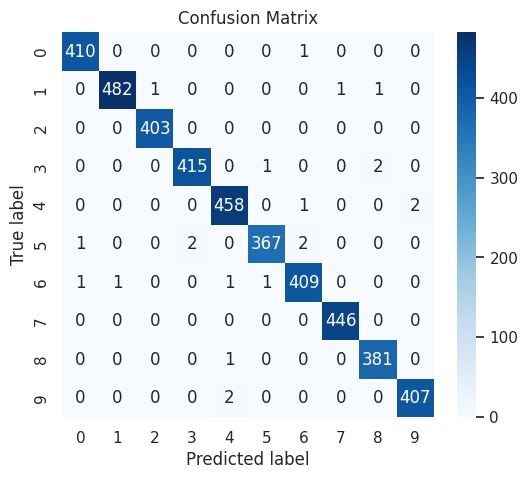

In [34]:
# Predict the values from the test dataset
Y_pred = model.predict(X_val)

# Convert predictions classes to one hot vectors
Y_pred_classes = np.argmax(Y_pred, axis=1)

# Convert test observations to one hot vectors
Y_true = np.argmax(y_val, axis=1)

# Compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)

# Plot the confusion matrix
def plot_confusion_matrix(cm, classes, cmap=plt.cm.Blues):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='g', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Plotting confusion matrix for 10 classes (0-9)
plot_confusion_matrix(confusion_mtx, classes=range(10))

In [36]:
#Classification Report
from sklearn.metrics import classification_report
print(classification_report(Y_true,Y_pred_classes,digits=4))

              precision    recall  f1-score   support

           0     0.9951    0.9976    0.9964       411
           1     0.9979    0.9938    0.9959       485
           2     0.9975    1.0000    0.9988       403
           3     0.9952    0.9928    0.9940       418
           4     0.9913    0.9935    0.9924       461
           5     0.9946    0.9866    0.9906       372
           6     0.9903    0.9903    0.9903       413
           7     0.9978    1.0000    0.9989       446
           8     0.9922    0.9974    0.9948       382
           9     0.9951    0.9951    0.9951       409

    accuracy                         0.9948      4200
   macro avg     0.9947    0.9947    0.9947      4200
weighted avg     0.9948    0.9948    0.9948      4200



Predicted: 0
True: 5


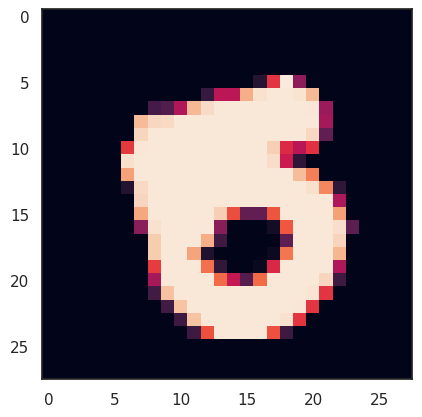

Predicted: 4
True: 6


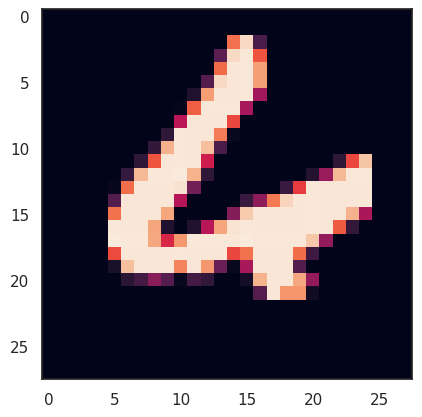

Predicted: 9
True: 4


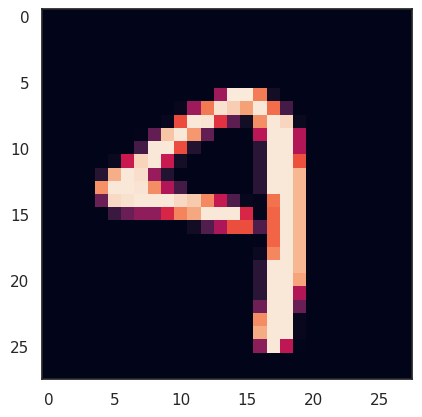

Predicted: 9
True: 4


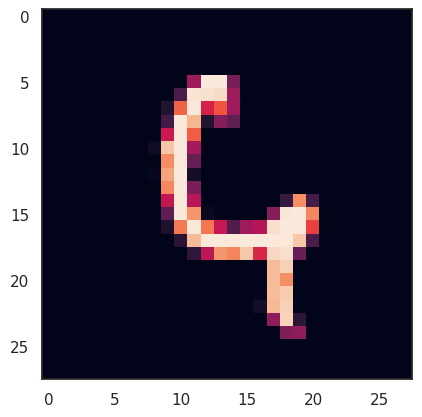

Predicted: 6
True: 5


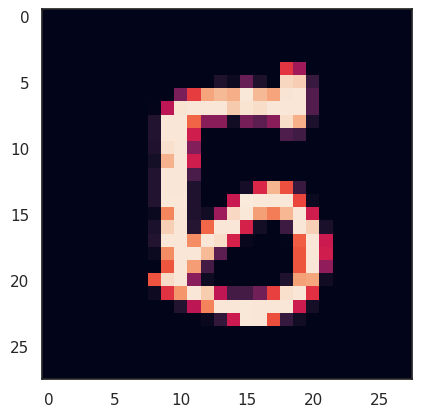

In [37]:
# Print some of these arrayes to show : Y_pred_classes_errors = Y_pred_classes[errors]

import matplotlib.pyplot as plt
# Get the errors
errors = (Y_pred_classes != Y_true)

Y_pred_classes_errors = Y_pred_classes[errors]
Y_true_errors = Y_true[errors]
X_test_errors = X_val[errors]

# Show some of the errors
for i in range(0, 5):
  print("Predicted:", Y_pred_classes_errors[i])
  print("True:", Y_true_errors[i])
  plt.imshow(X_test_errors[i][:,:,0])
  plt.show()

In [38]:
# predict results
results = model.predict(test)

# select the indix with the maximum probability
results = np.argmax(results,axis = 1)

results = pd.Series(results,name="Label")

875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [39]:
submission = pd.concat([pd.Series(range(1,28001),name = "ImageId"),results],axis = 1)

submission.to_csv("cnn_mnist_datagen.csv",index=False)